In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

import os
import sys
from pathlib import Path

sys.path.append(os.path.abspath(".."))
from tqdm.notebook import tqdm

tqdm.pandas()


BASE_DIR = Path.cwd().resolve().parent
print(f"BASE_DIR: {BASE_DIR}")

PR_DIR = BASE_DIR / "data" / "processed"
print(f"PR_DIR: {PR_DIR}")

RW_DIR = BASE_DIR / "data" / "raw"
print(f"RW_DIR: {RW_DIR}")

BASE_DIR: C:\Users\juanf\U\S7\5_bussiness\pr2
PR_DIR: C:\Users\juanf\U\S7\5_bussiness\pr2\data\processed
RW_DIR: C:\Users\juanf\U\S7\5_bussiness\pr2\data\raw


# Cargar

In [41]:
reviews = pd.read_csv(RW_DIR / "reviews.csv")
print(reviews.shape)
reviews.head()

(10000, 8)


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,7514
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0,2447.0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0,NaN
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0,NaN
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0,NaN
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0,NaN


In [42]:
fdt = pd.read_csv(RW_DIR / "Food_Delivery_Times.csv")
print(fdt.shape)
fdt.head()

(1000, 9)


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


# Clean Food delivery times

In [43]:
fdt.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    str    
 3   Traffic_Level           970 non-null    str    
 4   Time_of_Day             970 non-null    str    
 5   Vehicle_Type            1000 non-null   str    
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 70.4 KB


In [44]:
fdt.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


## Duplicados

In [45]:
fdt.duplicated().sum()

np.int64(0)

## Faltantes

In [46]:
for i in fdt:
    if fdt[i].isnull().sum() > 0:
        print(f"{i} : {fdt[i].isnull().sum()}")

Weather : 30
Traffic_Level : 30
Time_of_Day : 30
Courier_Experience_yrs : 30


In [47]:
fdt["Weather"] = fdt["Weather"].fillna(fdt["Weather"].mode()[0])
fdt["Traffic_Level"] = fdt["Traffic_Level"].fillna(fdt["Traffic_Level"].mode()[0])
fdt["Time_of_Day"] = fdt["Time_of_Day"].fillna(fdt["Time_of_Day"].mode()[0])

fdt["Courier_Experience_yrs"] = fdt["Courier_Experience_yrs"].fillna(
    fdt["Courier_Experience_yrs"].median()
)

In [48]:
fdt.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

## Gráficos

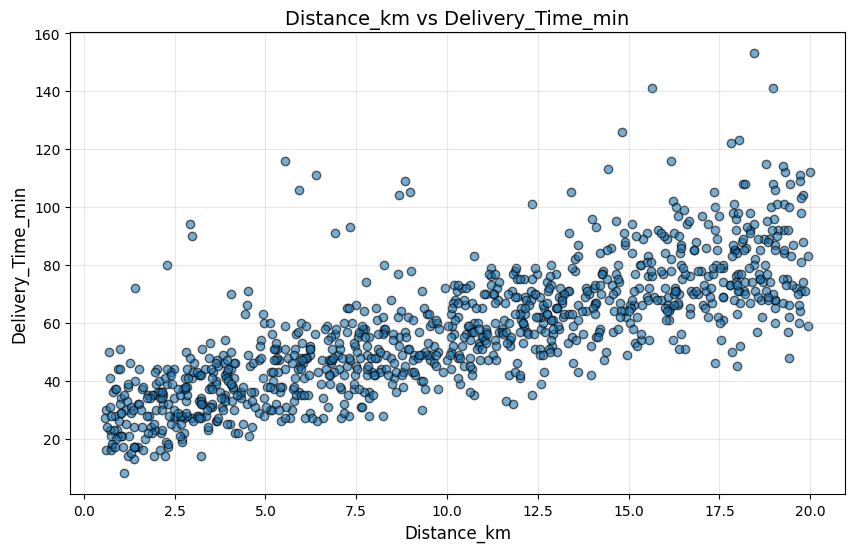

In [49]:
plt.figure(figsize=(10, 6))
plt.scatter(fdt["Distance_km"], fdt["Delivery_Time_min"], alpha=0.6, edgecolor="k")
plt.title("Distance_km vs Delivery_Time_min", fontsize=14)
plt.xlabel("Distance_km", fontsize=12)
plt.ylabel("Delivery_Time_min", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

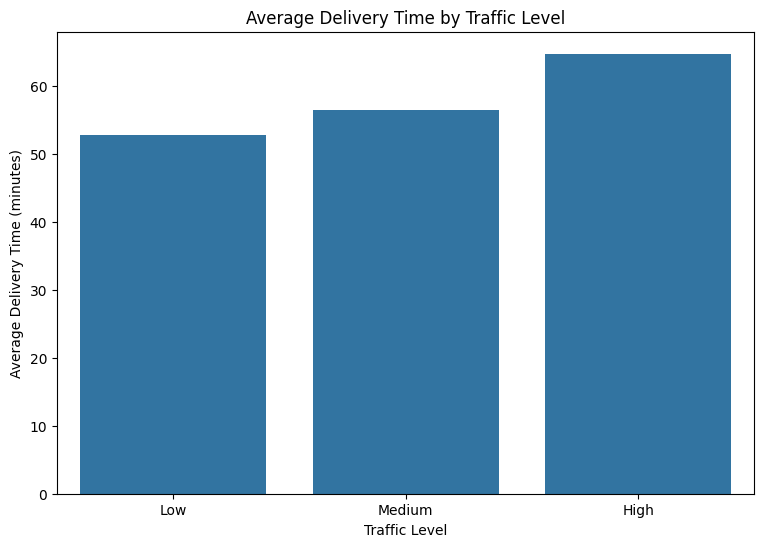

In [50]:
plt.figure(figsize=(9, 6))
sns.barplot(x="Traffic_Level", y="Delivery_Time_min", data=fdt, errorbar=None)
plt.title("Average Delivery Time by Traffic Level")
plt.xlabel("Traffic Level")
plt.ylabel("Average Delivery Time (minutes)")
plt.show()

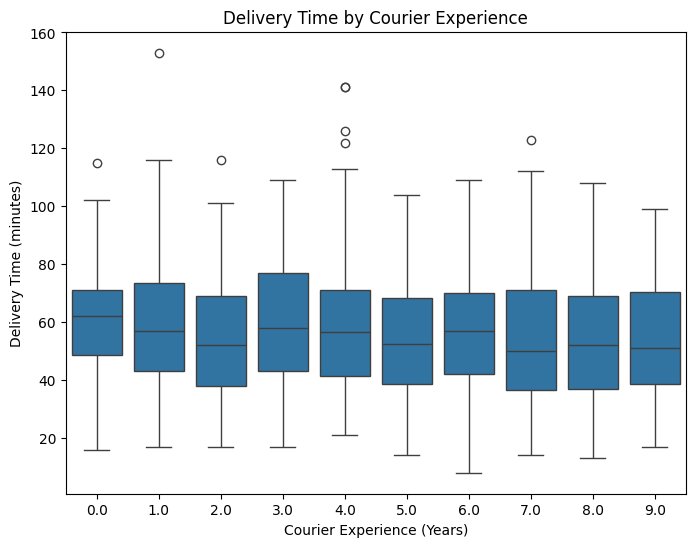

In [51]:
plt.figure(figsize=(8, 6))
sns.boxplot(x="Courier_Experience_yrs", y="Delivery_Time_min", data=fdt)
plt.title("Delivery Time by Courier Experience")
plt.xlabel("Courier Experience (Years)")
plt.ylabel("Delivery Time (minutes)")
plt.show()


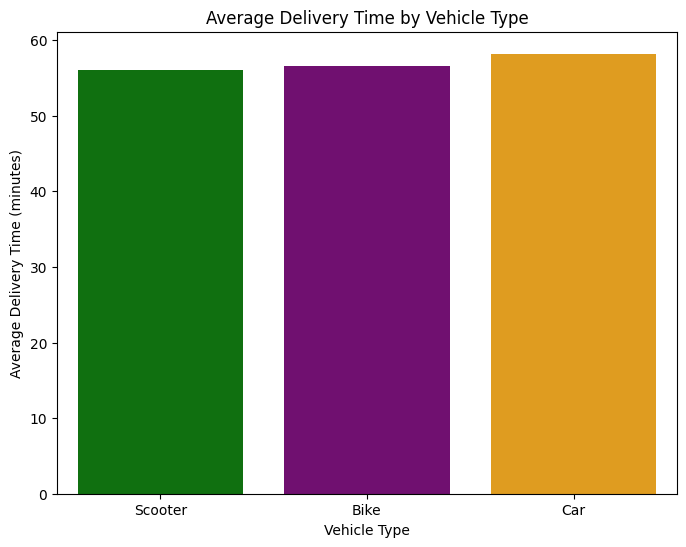

In [52]:
plt.figure(figsize=(8, 6))
sns.barplot(
    x="Vehicle_Type",
    y="Delivery_Time_min",
    data=fdt,
    errorbar=None,
    hue="Vehicle_Type",
    palette={"Scooter": "green", "Bike": "purple", "Car": "orange"},
)
plt.title("Average Delivery Time by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Delivery Time (minutes)")
plt.show()


## Exportar

In [53]:
fdt.to_csv(PR_DIR / "cleaned_food_delivery_times.csv", index=False)

# Clean reviews

In [54]:
reviews.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,7514
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0,2447.0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0,NaN
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0,NaN
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0,NaN
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0,NaN


In [55]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Restaurant  10000 non-null  str    
 1   Reviewer    9962 non-null   str    
 2   Review      9955 non-null   str    
 3   Rating      9962 non-null   str    
 4   Metadata    9962 non-null   str    
 5   Time        9962 non-null   str    
 6   Pictures    10000 non-null  int64  
 7   7514        1 non-null      float64
dtypes: float64(1), int64(1), str(6)
memory usage: 625.1 KB


## Faltantes

In [56]:
reviews.dropna(subset=["Review"], inplace=True)
reviews.info()

<class 'pandas.DataFrame'>
Index: 9955 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Restaurant  9955 non-null   str    
 1   Reviewer    9955 non-null   str    
 2   Review      9955 non-null   str    
 3   Rating      9955 non-null   str    
 4   Metadata    9955 non-null   str    
 5   Time        9955 non-null   str    
 6   Pictures    9955 non-null   int64  
 7   7514        1 non-null      float64
dtypes: float64(1), int64(1), str(6)
memory usage: 700.0 KB


## Eliminar columnas

In [ ]:
reviews.drop(
    columns=["Restaurant", "Reviewer", "Metadata", "Time", "Pictures", "7514"],
    inplace=True,
)

## Manejar rating

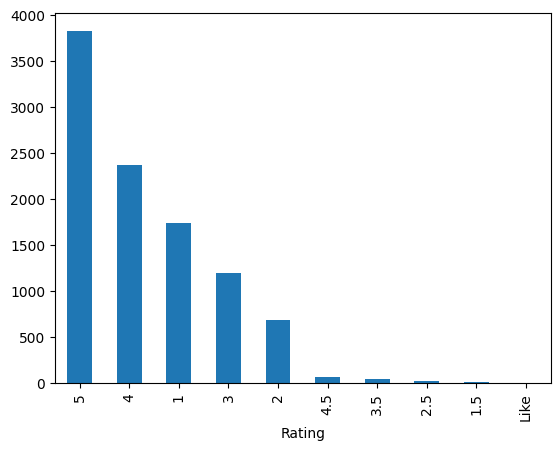

In [ ]:
reviews["Rating"].value_counts().plot.bar()
plt.show()

In [ ]:
reviews = reviews[reviews["Rating"].isin(["1", "2", "3", "4", "5"])]

In [60]:
reviews.shape

(9810, 2)

In [62]:
reviews.head()

,Review,Rating
0,"The ambience was good, food was quite good . h...",5
1,Ambience is too good for a pleasant evening. S...,5
2,A must try.. great food great ambience. Thnx f...,5
3,Soumen das and Arun was a great guy. Only beca...,5
4,Food is good.we ordered Kodi drumsticks and ba...,5


## Exportar

In [63]:
reviews.to_csv(PR_DIR / "cleaned_reviews.csv", index=True)